---
# Exemple de régression avec une forêt aléatoire
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/random-forest-example.png"  width="500" />
    <div>
    <font size="1.5">Image Source: https://blog.roboflow.com/what-is-dimensionality-reduction//</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous verrons un exemple de régression de données utilisant un modèle de forêt aléatoire. 

## Table des matières
1. Pourquoi utiliser un modèle de régression aléatoire?
2. Préparation des données.
3. Entraînement du modèle de forêt aléatoire.
4. Identification des variables les plus importantes déterminant le prix d'une maison.

#### Importation des librairies utilisées.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn import preprocessing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set(color_codes=True)

seed = 42
np.random.seed(seed)

Dans cet exemple, nous allons appliquer la régression par forêt aléatoire afin de prédire le prix, dans
les années 1970, des maisons dans la région de Boston au Massachusetts (États-Unis).

Le jeu de données contient 14 variables. Toutes les données sont numériques. Voici la liste des variables mesurées. L'objectif est de déterminer comment le prix médian des maisons (`MEDV`) varie en fonction des 13 autres variables:

- `CRIM`:  taux de criminalité.
- `ZN`:  proportion de terrain résidentiel zoné pour les lots de plus de 25 000 pi^2.
- `INDUS`:  proportion d'acres commerciales non commerciales par ville.
- `CHAS`:  indicateur de proximité avec la Charles River (1 si proche de la rivière, 0 sinon).
- `NOX`:  concentration d'oxydes d'azote (parties par 10 millions).
- `RM`:  nombre moyen de pièces par logement.
- `AGE`:  proportion d'unités construites avant 1940 et occupées par leur propriétaire.
- `DIS`:  distances pondérées jusqu'à cinq centres d'emploi de Boston.
- `RAD`:  indice d'accessibilité aux autoroutes radiales.
- `TAX`:  taux d'impôt foncier sur la valeur totale par tranche de ~\$10 000.
- `PTRATIO`:  ratio élèves-enseignants par ville.
- `B`:  $1000(B_k - 0.63)^2$ où $B_k$ est une variable associée à l'étude.
- `LSTAT`:  pourcentage de classes défavorisées dans la population.
- `MEDV`: valeur médiane des maisons unifamiliales détenues par leurs occupants dans un quartier donné, en k$.

Ce jeu de données est constitué de données hétéroclites qui varient de façon discontinue.

## Pourquoi utiliser un modèle de forêt aléatoire?

La régression sert à prédire une réponse $y$, qui est une variable numérique, en fonction de plusieurs variables $x_{i}$. Soit l'équation suivante

$$y=f(x_{1}, \cdots, x_{N}, \Theta)$$

où $\Theta$ représente l'ensemble des paramètres de la fonction $f$. Dans plusieurs domaines, comme en physique, on peut
dériver analytiquement une telle formule basée sur les lois de la nature. Dans les sciences de la vie et les sciences
sociales, c'est généralement impossible dû au grand nombre de phénomènes impliqués lors de la prise de données. La
modélisation par forêt aléatoire permet de se libérer de cette contrainte irréaliste en modélisation analytique. De
par sa nature, la forêt aléatoire permet d'explorer naturellement un très grand nombre d'interactions entre les
différentes variables sans avoir à les spécifier explicitement dans un modèle mathématique. C'est une des
multiples raisons pour lesquelles elles performent souvent mieux que d'autres méthodes non linéaires.

La forêt aléatoire est basée sur le modèle de l'arbre de décision. La figure suivante montre un exemple qui prédit une réponse $y$ en fonction de deux entrées $x_1$ et $x_2$.

<p>&nbsp;</p>
<div align="center">
    <img src= "images/decision-tree-example.png"  width="400" />
    <div>
    <font size="1.5">Image Source: https://blog.roboflow.com/what-is-dimensionality-reduction//</font>
    </div>
</div>
<p>&nbsp;</p>

La figure suivante montre comment les valeurs de $y$ varient de façon discontinue dans le plan $(x_1, x_2)$. 

<p>&nbsp;</p>
<div align="center">
    <img src= "images/decision-tree-six-steps.png"  width="400" />
    <div>
    <font size="1.5">Image Source: https://blog.roboflow.com/what-is-dimensionality-reduction//</font>
    </div>
</div>
<p>&nbsp;</p>

C'est très grossier comme prédiction. C'est pour cela qu'on utilise plutôt un ensemble d'arbres (figure suivante) dont on moyenne les prédictions. Chacun est différent des autres. C'est le modèle de la forêt aléatoire dont les prédictions sont souvent meilleures à celles de réseaux de neurones lorsqu'utilisés sur des jeux de données de type tabulaires (par ex. fichier Excel, CSV, etc).

<p>&nbsp;</p>
<div align="center">
    <img src= "images/random-forest-example.png"  width="500" />
    <div>
    <font size="1.5">Image Source: https://blog.roboflow.com/what-is-dimensionality-reduction//</font>
    </div>
</div>
<p>&nbsp;</p>

## Préparation des données

#### Lecture et affichage des données

In [2]:
# Lecture du jeu de données en format CSV.
dataset = pd.read_csv("fichiers/boston.csv")

Séparons les variables $X$ de la réponse $y$ à prédire.

In [3]:
X = pd.DataFrame(
    dataset,
    columns=[
        "CRIM",
        "ZN",
        "INDUS",
        "CHAS",
        "NOX",
        "RM",
        "AGE",
        "DIS",
        "RAD",
        "TAX",
        "PTRATIO",
        "B",
        "LSTAT",
    ],
)

# Liste des variables utilisées
feature_list = list(X.columns)

# Prix médian des maisons en k$
y = dataset['MEDV']

Nous visualisons ensuite la distribution des prix des maisons.

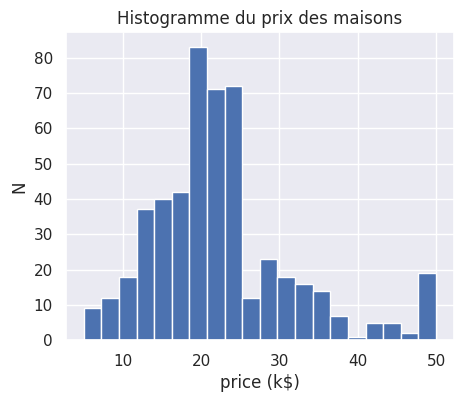

In [4]:
fig = plt.figure(figsize=(5, 4))
plt.hist(y, 20)
plt.title("Histogramme du prix des maisons")
plt.xlabel("price (k$)")
plt.ylabel("N")
plt.show()

C'est la quantité que l'on désire prédire en fonction des variables $x_{i}$ précédentes. Le prix maximum des
maisons est de $50\ 000~\$$.

Affichons les cinq premières lignes des variables X.

In [5]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


On constate que les valeurs couvrent différents ordres de grandeur. Il faudra donc les normaliser. Il convient toutefois de mentionner que les méthodes basées sur les arbres décisionnels (forêts aléatoires, XGBoost, etc.) ne sont pas affectées par cette opération. Toutefois, de nombreux modèles d'apprentissage automatique, dont les réseaux de neurones, requièrent de normaliser les données ; autant prendre cette habitude dès maintenant!

#### Séparation des données en ensembles d'entraînement (80 %) et de test (20 %)

Les données d'entraînement serviront à entraîner le modèle de régression. Autrement dit, il s'agit d'estimer la valeur du seuil τ de chaque nœud dans chaque arbre décisionnel de la forêt. Les données de test permettront ensuite d'évaluer la capacité du modèle à prédire correctement le prix de maisons jamais vues, c'est-à-dire sa capacité à généraliser sur de nouvelles données.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

Affichons les dimensions de X_train.

In [7]:
print(X_train.shape)

(404, 13)


#### Normalisation des données

**Remarque**: expérimentez avec d'autres types de [normalisation](https://scikit-learn.org/stable/api/sklearn.preprocessing.html).

In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Entraînement du modèle de forêt aléatoire

#### Sélection du régresseur

Définissons maintenant notre régresseur en utilisant la classe [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) de Scikit-learn.

On utilise les valeurs de paramètres suivants en se basant sur la documentation pour trouver les bons arguments:

- une forêt aléatoire de `100` estimateurs (*estimators*),
- une profondeur des arbres maximales de `6`, et
- un nombre minimal d'exemples (*samples*) de `3` pour diviser une feuille (*internal node*).

**Remarque**: testez différentes valeurs des paramètres de la fonction RandomForestRegressor pour améliorer les performances du régresseur. Vous pouvez utiliser un chatbot, comme Copilot ou ChatGPT, pour vous suggérer des valeurs. Par exemple, indiquez que vous utilisez un régresseur de type forêt aléatoire et que X_train a des dimensions (404, 13) avec des variables numériques. Vous pouvez même demander quels paramètres seraient les plus utiles à ajuster.

<p>&nbsp;</p>
<div align="center">
    <img src= "images/light-bulb-idea.jpeg"  width="150" />
    <div>
    <font size="1.5">Image Source: https://blog.roboflow.com/what-is-dimensionality-reduction//</font>
    </div>
</div>
<p>&nbsp;</p>

In [9]:
reg = RandomForestRegressor(max_depth=6, min_samples_split=3, n_estimators=100)

#### Entraînement du régresseur

Maintenant, entraînez le régresseur et effectuez les prédictions sur les données d'entraînement et de test.

In [10]:
reg.fit(X_train_s, y_train)
y_train_pred = reg.predict(X_train_s)
y_test_pred = reg.predict(X_test_s)

#### Affichage des résultats

Calculez maintenant les scores $R^2$ sur l'entraînement et le test.

In [11]:
score = r2_score(y_train, y_train_pred)
print("Valeur de R2 en entraînement:", round(100 * score, 1), "%")

score = r2_score(y_test, y_test_pred)
print("Valeur de R2 en test:", round(100 * score, 1), "%")

Valeur de R2 en entraînement: 94.9 %
Valeur de R2 en test: 89.1 %


La valeur du $R^2$ correspond à la fraction de la variance des données qui est expliquée par le modèle utilisé.

Le modèle explique environ $95~\%$ de la variabilité des données en entraînement et $89~\%$ de celles en test.

Affichons les valeurs prédites et réelles des maisons pour l'ensemble de test.

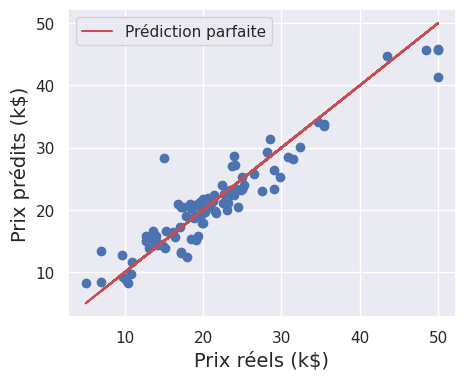

In [12]:
fig = plt.figure(figsize=(5, 4))
plt.plot(y_test, y_test_pred, "o")
plt.plot(y_test, y_test, "-r", label="Prédiction parfaite")

plt.xlabel("Prix réels (k$)", fontsize=14)
plt.ylabel("Prix prédits (k$)", fontsize=14)
plt.legend()
plt.show()

La droite rouge correspond à une prédiction parfaite. Mises à part quelques données
aberrantes (*outliers*), il y a une bonne adéquation entre les résultats réels et prédits.

## Identification des variables les plus importantes déterminant le prix d'une maison

<p>&nbsp;</p>
<div align="center">
    <img src= "images/inspector-with-magnifying-glass.jpeg"  width="200" />
    <div>
    <font size="0.5">Image Source: http://clipart-library.com/clipart/1416328.htm</font>
    </div>
</div>


Il est utile de faire de bonnes prédictions, mais il est également intéressant de connaître les variables qui influencent le plus le prix des maisons. Les courtiers immobiliers aiment prédire le prix d'une maison qu'ils ont à vendre. Les sociologues, eux, s'intéressent à la manière dont les variables socio-économiques affectent l'immobilier, et donc les conditions de vie, dans les différents quartiers d'une ville.

Les variables $x_{i}$ les plus importantes sont celles qui sont le plus souvent utilisées pour prendre des décisions à l'aide des arbres décisionnels constituant la forêt.

Le régresseur utilisé, « RandomForestRegressor », permet de calculer l'importance de chaque variable. Celle-ci prend une valeur entre 0 et 1 : 0 indique qu'elle n'est jamais utilisée, et 1, qu'elle est la seule utilisée parmi toutes. Dans ce dernier cas, la variable permet de prédire parfaitement la réponse.
La somme des importances sur l'ensemble des variables vaut 1.

In [13]:
# Importance de chaque variable
importances = list(reg.feature_importances_)

#### Affichage du diagramme d'importance des variables du jeu de données

On veut déterminer lesquelles sont les plus importantes et combien il y en a.

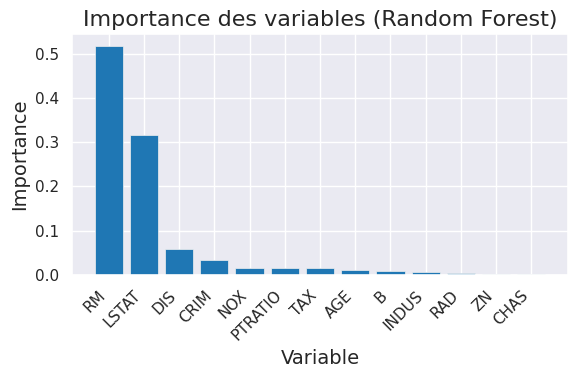

In [14]:
# Tri décroissant
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(6, 4))
plt.style.use("fivethirtyeight")

# Barplot
ax.bar(
    range(len(importances)),
    np.array(importances)[indices],
    color="#1f77b4"
)

# Labels
ax.set_xticks(range(len(importances)))
ax.set_xticklabels(np.array(feature_list)[indices], rotation=45, ha="right")

ax.set_ylabel("Importance", fontsize=14)
ax.set_xlabel("Variable", fontsize=14)
ax.set_title("Importance des variables (Random Forest)", fontsize=16)

# Cadre propre
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

Affichons l'importance de chaque variable en ordre décroissant.

In [15]:
df_importances = (
    pd.DataFrame({"feature": feature_list,
                  "importance": reg.feature_importances_})
    .sort_values("importance", ascending=False)
)

df_importances

,feature,importance
5,RM,0.519383
12,LSTAT,0.316907
7,DIS,0.058048
0,CRIM,0.033915
4,NOX,0.015208
10,PTRATIO,0.014912
9,TAX,0.014560
6,AGE,0.009507
11,B,0.007535
2,INDUS,0.005353


On voit que les variables RM (le nombre moyen de pièces par logement) et LSTAT (le pourcentage des classes défavorisées dans la population) sont de loin les plus importantes. Elles contribuent à 84 % de l'importance totale.

### Comment varie le prix des maisons en fonction des deux variables les plus importantes?

C'est bien de savoir quelles variables sont les plus déterminantes, c'est bien aussi de savoir comment chacune influence le prix des maisons. C'est ce que nous allons voir avec les deux variables principales.

#### Sélection des variables d'intérêt

In [16]:
var_int = ["RM", "LSTAT"]
x = X.loc[:, var_int]
x = pd.DataFrame(data=x, columns=var_int)

#### Affichage de l'effet de chaque variable sur le prix des maisons

Dans chaque panneau, la droite des moindres carrés est affichée ainsi que l'intervalle de confiance à $95~\%$.

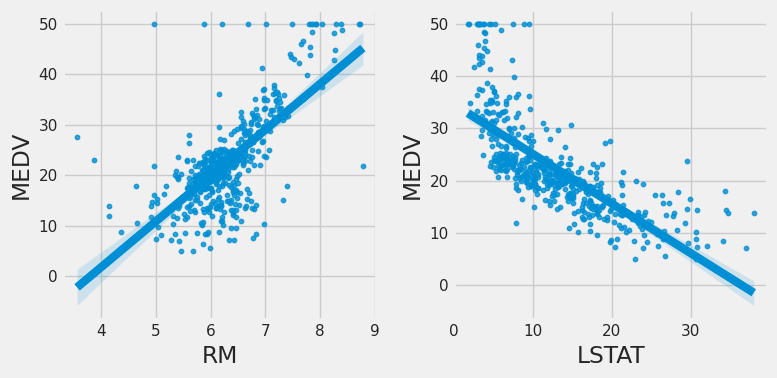

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

for ax, var in zip(axs, var_int):
    sns.regplot(x=x[var], y=y, ax=ax, scatter_kws={"s": 10})

plt.tight_layout()


On voit que le prix d'une maison augmente avec le nombre de chambres (RM) et diminue avec le
le pourcentage des classes défavorisées dans la population (LSAT). Une conclusion similaire
pourrait être tirée de bases de données contemporaines pour un très grand nombre de villes dans le monde.

Quelles seraient l'effet des performances (la valeur du $R^2$) si la forêt aléatoire n'utilisait que
les deux variables les plus importantes, soit `RM` et `LSAT`? 

On peut tester cet effet en effectuant l'entraînement du régresseur à nouveau, mais en utilisant cette fois uniquement les variables `RM` et `LSAT` et en utilisant le régresseur ayant les caractéristiques suivantes:

- une forêt aléatoire de `100` estimateurs (*estimators*),
- une profondeur des arbres maximales de `4`, et
- un nombre minimal d'exemples (*samples*) de `5` pour diviser une feuille (*internal node*).

In [18]:
X = X[['RM', 'LSTAT']]

# Liste des variables utilisées
feature_list = list(X.columns)

# Génération des ensembles d'entraînement
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=seed
)

# Normalisation des données
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Sélection du type de régresseur
reg = RandomForestRegressor(max_depth=4, min_samples_split=5, n_estimators=100)

# Entraînement du régresseur avec les données d'entraînement
reg.fit(X_train_s, y_train)

# Prédiction du prix des maisons pour les deux ensembles de données
y_train_pred = reg.predict(X_train_s)
y_test_pred = reg.predict(X_test_s)

# Affichage de la valeur du R2
score = r2_score(y_train, y_train_pred)
print("Valeur de R2 en entraînement:", round(100 * score, 1), "%")

score = r2_score(y_test, y_test_pred)
print("Valeur de R2 en test:", round(100 * score, 1), "%")

Valeur de R2 en entraînement: 85.6 %
Valeur de R2 en test: 74.1 %


Le R² en test est passé de 89,1 % à 74,1 %, soit une baisse de 15 %.

Cela montre à quel point les variables éliminées contribuaient initialement. Bien que les variables RM et LSAT soient les plus importantes, elles n'expliquent pas tout. Il faut y penser deux fois avant d'éliminer des variables dans un jeu de données.

Affichons à nouveau les valeurs prédites et réelles du prix des maisons pour l'ensemble de test.

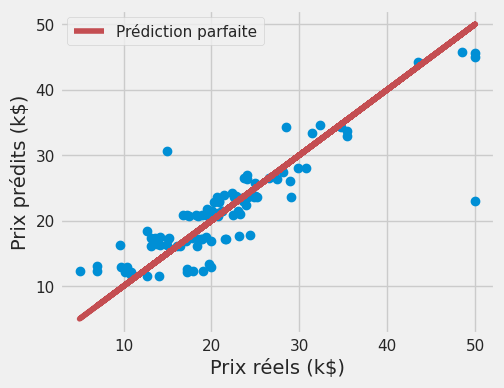

In [19]:
fig = plt.figure(figsize=(5, 4))
plt.plot(y_test, y_test_pred, "o")
plt.plot(y_test, y_test, "-r", label="Prédiction parfaite")

plt.xlabel("Prix réels (k$)", fontsize=14)
plt.ylabel("Prix prédits (k$)", fontsize=14)
plt.legend()
plt.show()

Les données sont désormais plus dispersées autour de la droite unité. Si les 11 variables éliminées n'avaient aucun effet sur le prix des maisons, la dispersion des données serait comparable à celle de la version précédente de la figure. Cela montre que les variables éliminées permettent d'affiner les prédictions du prix de vente des maisons.